### Read and validate data 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
import os

filepath = f'{os.path.dirname(os.getcwd())}/data/data_ready1603.pkl'
df = pd.read_pickle(filepath)
print(f"shape: {df.shape}")
print(f"columns: {df.columns.tolist()}")

feature_cols = [
    'qt_open_ended', 'qt_multiple_selection',
    'qt_single_selection', 'qt_rating',
    'num_answer_choices', 'avg_answer_choice_length',
    'word_count', 'prompt_length', 'avg_word_length',
    'pct_big_words', 'type_token_ratio', 'readability',
    'has_question_mark', 'is_personal', 'has_analytical',
    'has_negation', 'has_temporal', 'has_numbers',
    'is_complex_prompt', 'starts_with_why', 'starts_with_how',
    'starts_with_describe', 'starts_with_rate',
    'open_ended_ratio', 'position_in_survey',
    'survey_difficulty_score', 'num_questions_in_survey',
    'cat_business', 'cat_culture and arts', 'cat_food and lifestyle',
    'cat_health and wellness', 'cat_personal development',
    'cat_society', 'cat_sports', 'cat_technology',
]
missing = [f for f in feature_cols if f not in df.columns]
print(len(missing) == 0)
print(df[feature_cols].isna().sum().sum())
print(f"{len(feature_cols)} features ready")

/opt/miniconda3/envs/ds_assignment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shape: (3610410, 38)
columns: ['qt_open_ended', 'qt_multiple_selection', 'qt_single_selection', 'qt_rating', 'num_answer_choices', 'avg_answer_choice_length', 'word_count', 'prompt_length', 'avg_word_length', 'pct_big_words', 'type_token_ratio', 'readability', 'has_question_mark', 'is_personal', 'has_analytical', 'has_negation', 'has_temporal', 'has_numbers', 'is_complex_prompt', 'starts_with_why', 'starts_with_how', 'starts_with_describe', 'starts_with_rate', 'open_ended_ratio', 'position_in_survey', 'survey_difficulty_score', 'num_questions_in_survey', 'cat_business', 'cat_culture and arts', 'cat_food and lifestyle', 'cat_health and wellness', 'cat_personal development', 'cat_society', 'cat_sports', 'cat_technology', 'response_id', 'survey_id', 'answer_time_ms']
True
0
35 features ready


### Train Test split and Leakage check

In [2]:
# we need to be careful with the response ids. one response id can belogn to either in train or in test not in both.
response_ids = df['response_id'].unique()

train_ids, test_ids = train_test_split(response_ids, test_size=0.2, random_state=42)

df_train = df[df['response_id'].isin(train_ids)].copy() # train dataset for the final train 
df_test  = df[df['response_id'].isin(test_ids)].copy() # test datset for the uknown response ids test dataset 

# leakage check
leakage = set(train_ids) & set(test_ids)
print(len(leakage)) # 0 no leakage found 

print(f"train: {len(df_train):,} rows - {len(train_ids):,} response ids") # 2,888,485 rows - 306,052 response ids
print(f"test: {len(df_test):,} rows - {len(test_ids):,} response ids") # 721,925 rows - 76,514 response ids

X_train = df_train[feature_cols].astype(float)
X_test  = df_test[feature_cols].astype(float)

y_train = df_train['answer_time_ms']
y_test  = df_test['answer_time_ms']

0
train: 2,888,485 rows - 306,052 response ids
test: 721,925 rows - 76,514 response ids


### Baseline creation

I saw from a paper BEA 2024 that a regressor (dummyregressor) was used as a reference point. In this paper, the researcher where trying to predict the response time and dificulty of questions of medical examinations. thus i figured to use the median per
question type as a baseline since question type alone explains almost 81% percent of the variance, as a metric to compare when improving and tuning our models. From this paper also I am borrwing the idea of lasso as it was ranked as the 2nd most insightfull model for response time, while also i did follow their structure on caclulating the features i did in the feature engineering part. their results showd that counter features and "cognitive" (analytical thinking etc) features where more important than bert embeddings. Embeddings where left last to try 

In [8]:
def get_qtype(row):
    for col in ['qt_open_ended', 'qt_multiple_selection', 'qt_single_selection', 'qt_rating']:
        if row[col] == 1:
            return col
    return 'qt_single_selection' # as an edge case randomly

df_train['_qtype'] = df_train[
    ['qt_open_ended', 'qt_multiple_selection', 'qt_single_selection', 'qt_rating']
].apply(get_qtype, axis=1)

df_test['_qtype'] = df_test[
    ['qt_open_ended', 'qt_multiple_selection', 'qt_single_selection', 'qt_rating']
].apply(get_qtype, axis=1)

# Compute medians on train only
baseline_medians = df_train.groupby('_qtype')['answer_time_ms'].median()
print(f"Baseline medians:\n{baseline_medians}")

baseline_preds = df_test['_qtype'].map(baseline_medians)

baseline_mae = mean_absolute_error(df_test['answer_time_ms'], baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(df_test['answer_time_ms'], baseline_preds))
baseline_r2 = r2_score(df_test['answer_time_ms'], baseline_preds)

print(f"\nBaseline Results:")
print(f"MAE: {baseline_mae:,.0f} ms ({baseline_mae/1000:.1f} sec)")
print(f"RMSE: {baseline_rmse:,.0f} ms ({baseline_rmse/1000:.1f} sec)")
print(f"R squared: {baseline_r2:.4f}")

# Baseline medians:
# _qtype
# qt_multiple_selection 10872.0
# qt_open_ended 25621.0
# qt_rating 3600.0
# qt_single_selection 5190.0
# Name: answer_time_ms, dtype: float64

# Baseline Results:
# MAE: 2,767 ms (2.8 sec)
# RMSE: 4,235 ms (4.2 sec)
# R squared:   0.8125

# baseline does seems to explain preety much 81% of our data variance 

Baseline medians:
_qtype
qt_multiple_selection    10872.0
qt_open_ended            25621.0
qt_rating                 3600.0
qt_single_selection       5190.0
Name: answer_time_ms, dtype: float64

Baseline Results:
MAE: 2,767 ms (2.8 sec)
RMSE: 4,235 ms (4.2 sec)
R squared: 0.8125


#### LASSO

In [3]:
# remove columns from features that i saw from eda that may add noice or wouldnt help in lasso - non linearity 
# If both Papprox0 and Sapprox0 -> no signal at all -> drop
# If S>P -> non-linear or monotonic signal only -> Lasso cannot capture it → drop.

lasso_drop = [
    # P=-0.03, S=0.21 — non-linear monotonic signal only (S>>P).
    # Lasso cannot capture this, keep only for LightGBM.
    'qt_multiple_selection',

    # P=-0.01, S=-0.06 — both near zero, no meaningful signal.
    'pct_big_words',

    # P=-0.05, S=-0.02 — both near zero, also highly correlated
    # with word_count so adds redundancy without signal.
    'type_token_ratio',

    # P=0.01, S=0.00, Δmedian=1130ms — essentially zero signal
    # on both metrics.
    'has_negation',

    # P=-0.06, S=-0.06 — very small signal, not worth the noise
    # introduced in a linear model.
    'has_numbers',

    # P=0.01, S=0.01 — no signal, already captured implicitly
    # by survey_difficulty_score.
    'num_questions_in_survey',

    # All cat_* dummies: P≈0, S≈0, Δmedian < 700ms across all
    # categories. No meaningful signal for a linear model.
    'cat_business', 'cat_culture and arts', 'cat_food and lifestyle',
    'cat_health and wellness', 'cat_personal development',
    'cat_society', 'cat_sports', 'cat_technology',
]

lasso_features = [f for f in feature_cols if f not in lasso_drop]
print(f"Total features for Lasso: {len(lasso_features)}")
print(lasso_features)


Total features for Lasso: 21
['qt_open_ended', 'qt_single_selection', 'qt_rating', 'num_answer_choices', 'avg_answer_choice_length', 'word_count', 'prompt_length', 'avg_word_length', 'readability', 'has_question_mark', 'is_personal', 'has_analytical', 'has_temporal', 'is_complex_prompt', 'starts_with_why', 'starts_with_how', 'starts_with_describe', 'starts_with_rate', 'open_ended_ratio', 'position_in_survey', 'survey_difficulty_score']


#### lasso alpha tuning

In [ ]:
from sklearn.linear_model import Lasso, LassoCV

np.random.seed(42)
idx = np.random.choice(len(X_train), size=1_000_000, replace=False)

X_sub = X_train[lasso_features].iloc[idx]  # lasso_features
y_sub = y_train.iloc[idx]

scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)

lasso_cv = LassoCV(
    alphas=np.logspace(-4, 1, 30),  # denser grid, was too sparse before
    cv=5, max_iter=10000, n_jobs=-1
)
lasso_cv.fit(X_sub_scaled, y_sub)
best_alpha = lasso_cv.alpha_

# sanity check — if best_alpha is at the edge of the grid, the range needs expanding
print(f"Best alpha: {best_alpha:.6f}")
print(f"Grid min: {lasso_cv.alphas_.min():.6f}, Grid max: {lasso_cv.alphas_.max():.1f}")

best_alpha_idx = np.where(lasso_cv.alphas_ == lasso_cv.alpha_)[0][0]
cv_rmse_mean_lasso = np.sqrt(lasso_cv.mse_path_[best_alpha_idx].mean())
cv_rmse_std_lasso  = np.sqrt(lasso_cv.mse_path_[best_alpha_idx].std())
print(f"cv rmse: {cv_rmse_mean_lasso:,.0f} with std {cv_rmse_std_lasso:.0f}ms")

# Best alpha: 0.007880
# Grid min: 0.000100, Grid max: 10.0
# cv rmse: 4,060 with std 397ms

Best alpha: 0.007880
Grid min: 0.000100, Grid max: 10.0
cv rmse: 4,060 ± 397ms


#### Cross validation with best alpha

In [ ]:
from sklearn.model_selection import GroupKFold

X_cv = X_train[lasso_features]
y_cv = y_train
groups = df_train['response_id']

gkf = GroupKFold(n_splits=5)
cv_maes = []
cv_r2s = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cv, y_cv, groups)):
    fold_scaler = StandardScaler()
    X_fold_train = fold_scaler.fit_transform(X_cv.iloc[train_idx])
    X_fold_test = fold_scaler.transform(X_cv.iloc[test_idx])

    m = Lasso(alpha=0.007880, max_iter=10000)
    m.fit(X_fold_train, y_cv.iloc[train_idx])
    preds = m.predict(X_fold_test)

    mae = mean_absolute_error(y_cv.iloc[test_idx], preds)
    r2 = r2_score(y_cv.iloc[test_idx], preds)
    cv_maes.append(mae)
    cv_r2s.append(r2)
    print(f"fold {fold+1}: mae={mae:,.0f}ms  r squared={r2:.4f}")

lasso_cv_mae = np.mean(cv_maes)
lasso_cv_r_squared = np.mean(cv_r2s)
print(f"Lasso cv results with 5 folds:")
print(f"mae: {lasso_cv_mae:,.0f} with std {np.std(cv_maes):.0f}ms")
print(f"r squared:  {lasso_cv_r_squared:.4f} with std {np.std(cv_r2s):.4f}")

# fold 1: mae=2,629ms  r squared=0.8267
# fold 2: mae=2,626ms  r squared=0.8274
# fold 3: mae=2,625ms  r squared=0.8276
# fold 4: mae=2,631ms  r squared=0.8270
# fold 5: mae=2,630ms  r squared=0.8271
# Lasso cv results with 5 folds:
# mae: 2,628 with std 2ms
# r squared:  0.8272 with std 0.0003

fold 1: mae=2,629ms  r squared=0.8267
fold 2: mae=2,626ms  r squared=0.8274
fold 3: mae=2,625ms  r squared=0.8276
fold 4: mae=2,631ms  r squared=0.8270
fold 5: mae=2,630ms  r squared=0.8271
Lasso cv results with 5 folds:
mae: 2,628 with std 2ms
r squared:  0.8272 with std 0.0003


#### final train and test for evaluation

In [ ]:
final_scaler = StandardScaler()

X_train_scaled = final_scaler.fit_transform(X_train[lasso_features])
X_test_scaled  = final_scaler.transform(X_test[lasso_features])

lasso = Lasso(alpha=0.007880, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso final trining and evaluation results")
print(f"mae: {mae_lasso:,.0f}ms ({mae_lasso/1000:.1f} sec)")
print(f"rmse: {rmse_lasso:,.0f}ms ({rmse_lasso/1000:.1f} sec)")
print(f"r squared: {r2_lasso:.4f}")
print(f"lasso vs bmaaseline:")
print(f"mae improvement: {(baseline_mae - mae_lasso)/baseline_mae*100:.1f}%")
print(f"r squared imrpovement:  {r2_lasso - baseline_r2:.4f}")

# Lasso final trining and evaluation results
# mae: 2,629ms (2.6 sec)
# rmse: 4,064ms (4.1 sec)
# r squared: 0.8273
# lasso vs bmaaseline:
# mae improvement: 5.0%
# r squared imrpovement:  0.0148

Lasso final trining and evaluation results
mae: 2,629ms (2.6 sec)
rmse: 4,064ms (4.1 sec)
r squared: 0.8273
lasso vs bmaaseline:


NameError: name 'baseline_mae' is not defined

In [9]:
print(f"mae improvement: {(baseline_mae - mae_lasso)/baseline_mae*100:.1f}%")
print(f"r squared imrpovement:  {r2_lasso - baseline_r2:.4f}")

mae improvement: 5.0%
r squared imrpovement:  0.0148


In [11]:
# get lasso importances
lasso_importance = pd.Series(
    lasso.coef_,
    index=lasso_features
).sort_values(key=abs, ascending=False)

import os
os.getcwd()

parent_folder = os.path.dirname(os.getcwd())
filepath = f'{parent_folder}/results/lasso_importances_final.csv'
lasso_importance.to_csv(filepath)

In [ ]:
# Lasso Coefficient Analysis

# Question type features dominate as expected — qt_open_ended (+6301 ms) is by far the most
# important feature, consistent with the baseline r squared = 0.81 and Pearson = 0.86 from EDA.
# qt_rating (-3261 ms) and qt_single_selection (-2606 ms) confirm that click-based questions
# are significantly faster, aligning with our correlation analysis.

# prompt_length (+1405 ms) is the second most important feature after question types,
# confirming the BEA 2024 paper finding that length-related features are strong predictors
# of response time.

# Multicollinearity is visible in the prompt_length / word_count / avg_word_length trio:
# prompt_length is positive (+1405 ms) while word_count (-290 ms) and avg_word_length (-650 ms)
# are negative. The signs are not individually interpretable — the Lasso is splitting the effect
# across correlated features. The combined effect approximates average word length.
# For pure interpretability, only one of the three should be kept.

# open_ended_ratio is negative (-188 ms) despite the expectation of a positive effect.
# This acts as a correction term — qt_open_ended already captures the main effect,
# and the ratio adjusts for surveys with more open-ended questions having slightly lower
# per-question time once the question type is already accounted for.

# Borderline features were validated by the Lasso:
# - position_in_survey (3 ms) and starts_with_why (-5 ms) were effectively zeroed out,
#   confirming the EDA finding of near-zero signal
# - is_complex_prompt (58 ms) survived but with a small coefficient,
#   consistent with its borderline classification from the correlation analysis

# has_analytical (-128 ms) and is_personal (-119 ms) show meaningful effects —
# analytical prompts surprisingly reduce response time, possibly because they overlap
# with rating or single-selection patterns in the data.

In [15]:
continuous_features = [
    'num_answer_choices', 'avg_answer_choice_length',
     'prompt_length', 'word_count',
    'readability', 'avg_word_length', 'open_ended_ratio',
    'avg_answer_choice_length', 'survey_difficulty_score',
    'position_in_survey'
]

binary_features = [
    'has_question_mark', 'is_personal', 'is_complex_prompt',
    'has_analytical', 'has_temporal', 'starts_with_how',
    'starts_with_why', 'starts_with_describe', 'starts_with_rate',
    'qt_open_ended', 'qt_rating', 'qt_single_selection'
]

num_answer_choices
avg_answer_choice_length
prompt_length
word_count
readability
avg_word_length
open_ended_ratio
avg_answer_choice_length
survey_difficulty_score
position_in_survey


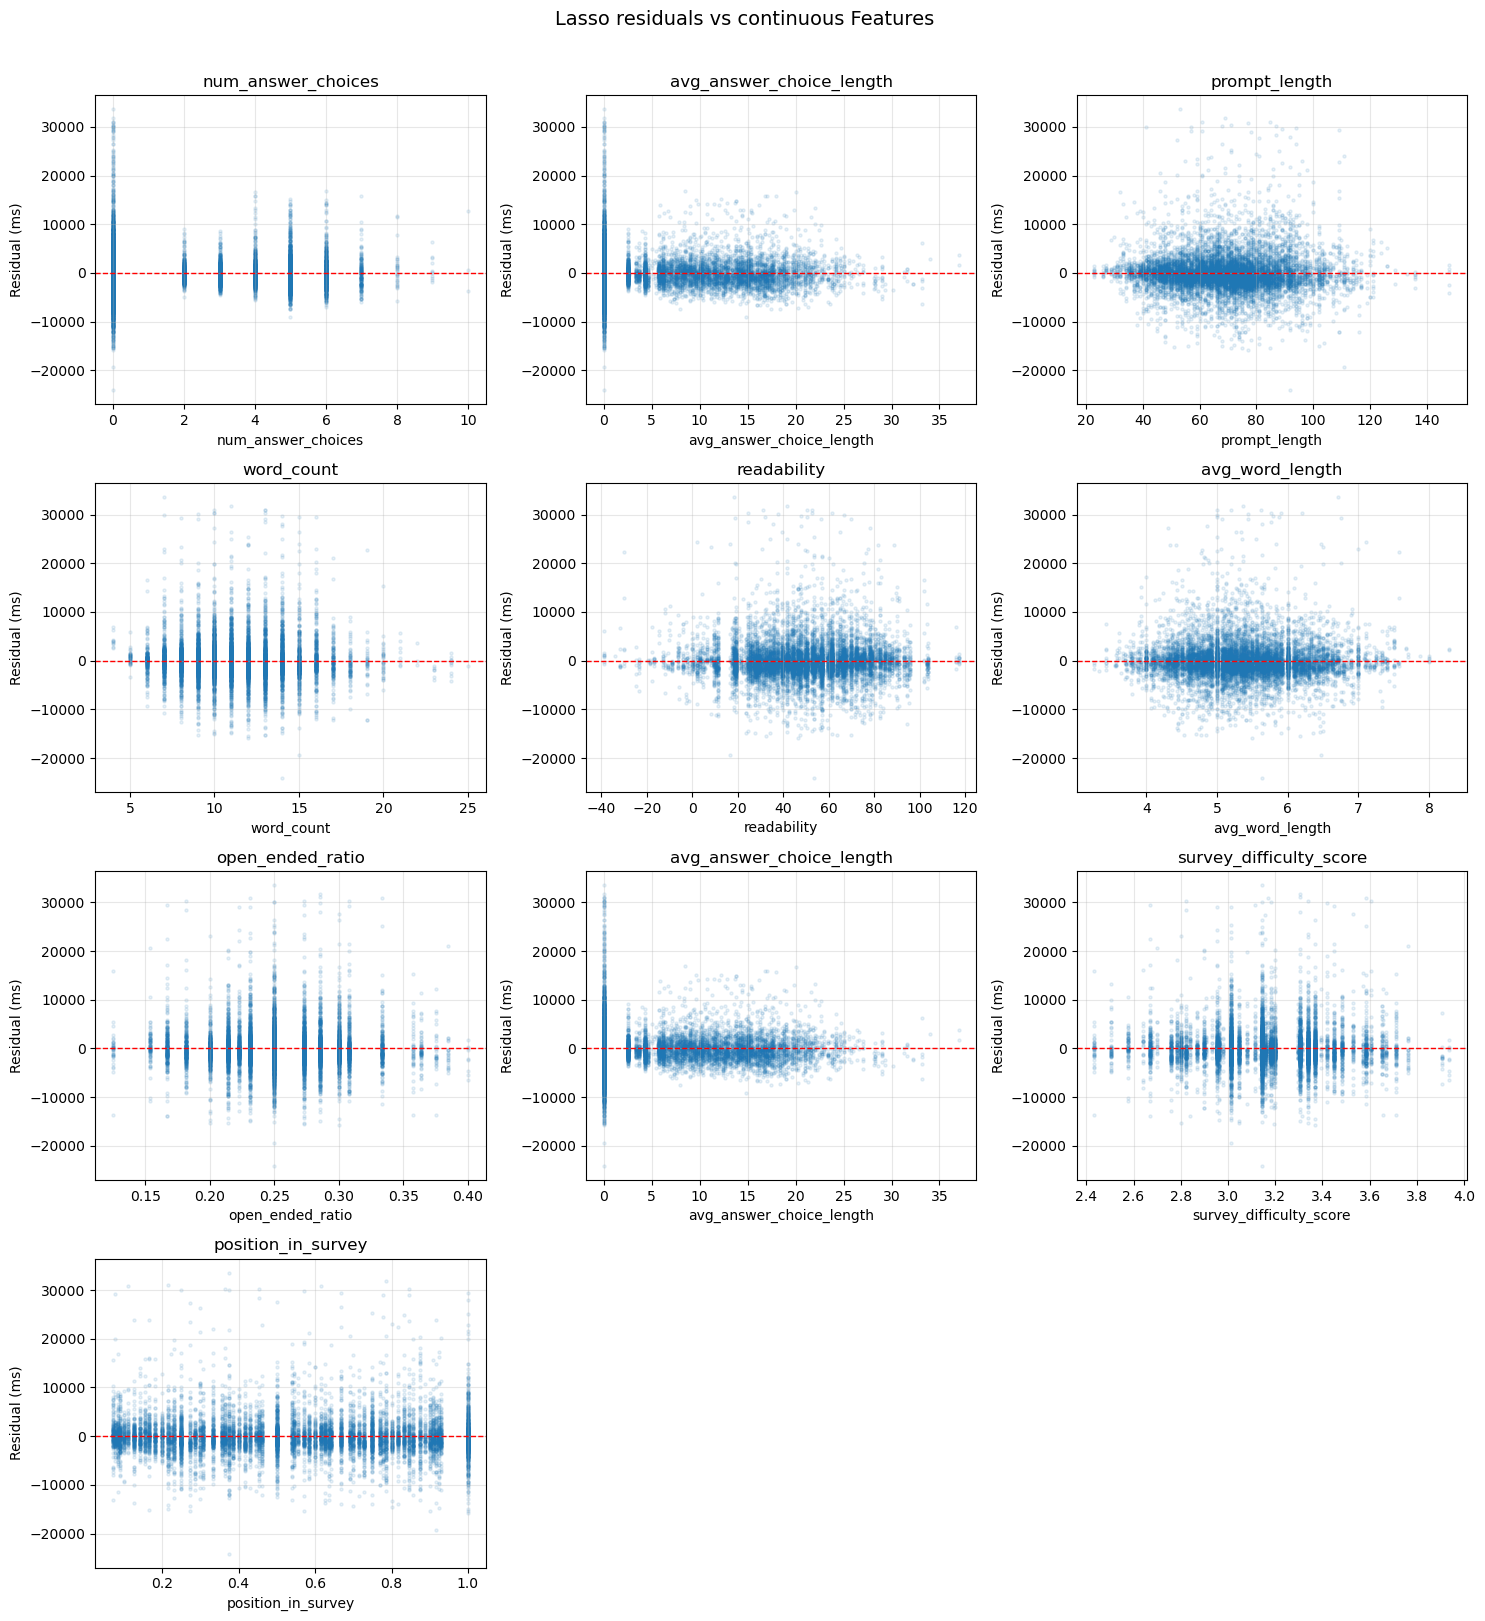

In [16]:
import matplotlib.pyplot as plt


n_cols = 3
n_rows = int(np.ceil(len(continuous_features) / n_cols))
lasso_residuals = y_test - y_pred_lasso

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=10_000, replace=False)

residuals_sample = lasso_residuals.iloc[sample_idx]
X_test_sample = X_test[lasso_features].iloc[sample_idx]

# Scatter: residuals vs continuous features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    print(feature)
    axes[i].scatter(
        X_test_sample[feature],
        residuals_sample,
        alpha=0.1, s=5
    )
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Residual (ms)')
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Lasso residuals vs continuous Features',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Continuous features: the variance pattern across all features reflects the question type
# distribution at each value of x rather than missing non-linear signal. num_answer_choices=0
# contains both open_ended and rating questions — the two extremes of response time — causing
# high variance at 0 that narrows as the mix becomes more homogeneous. This is inherent data
# structure, not a Lasso limitation, and LightGBM is not expected to correct it.

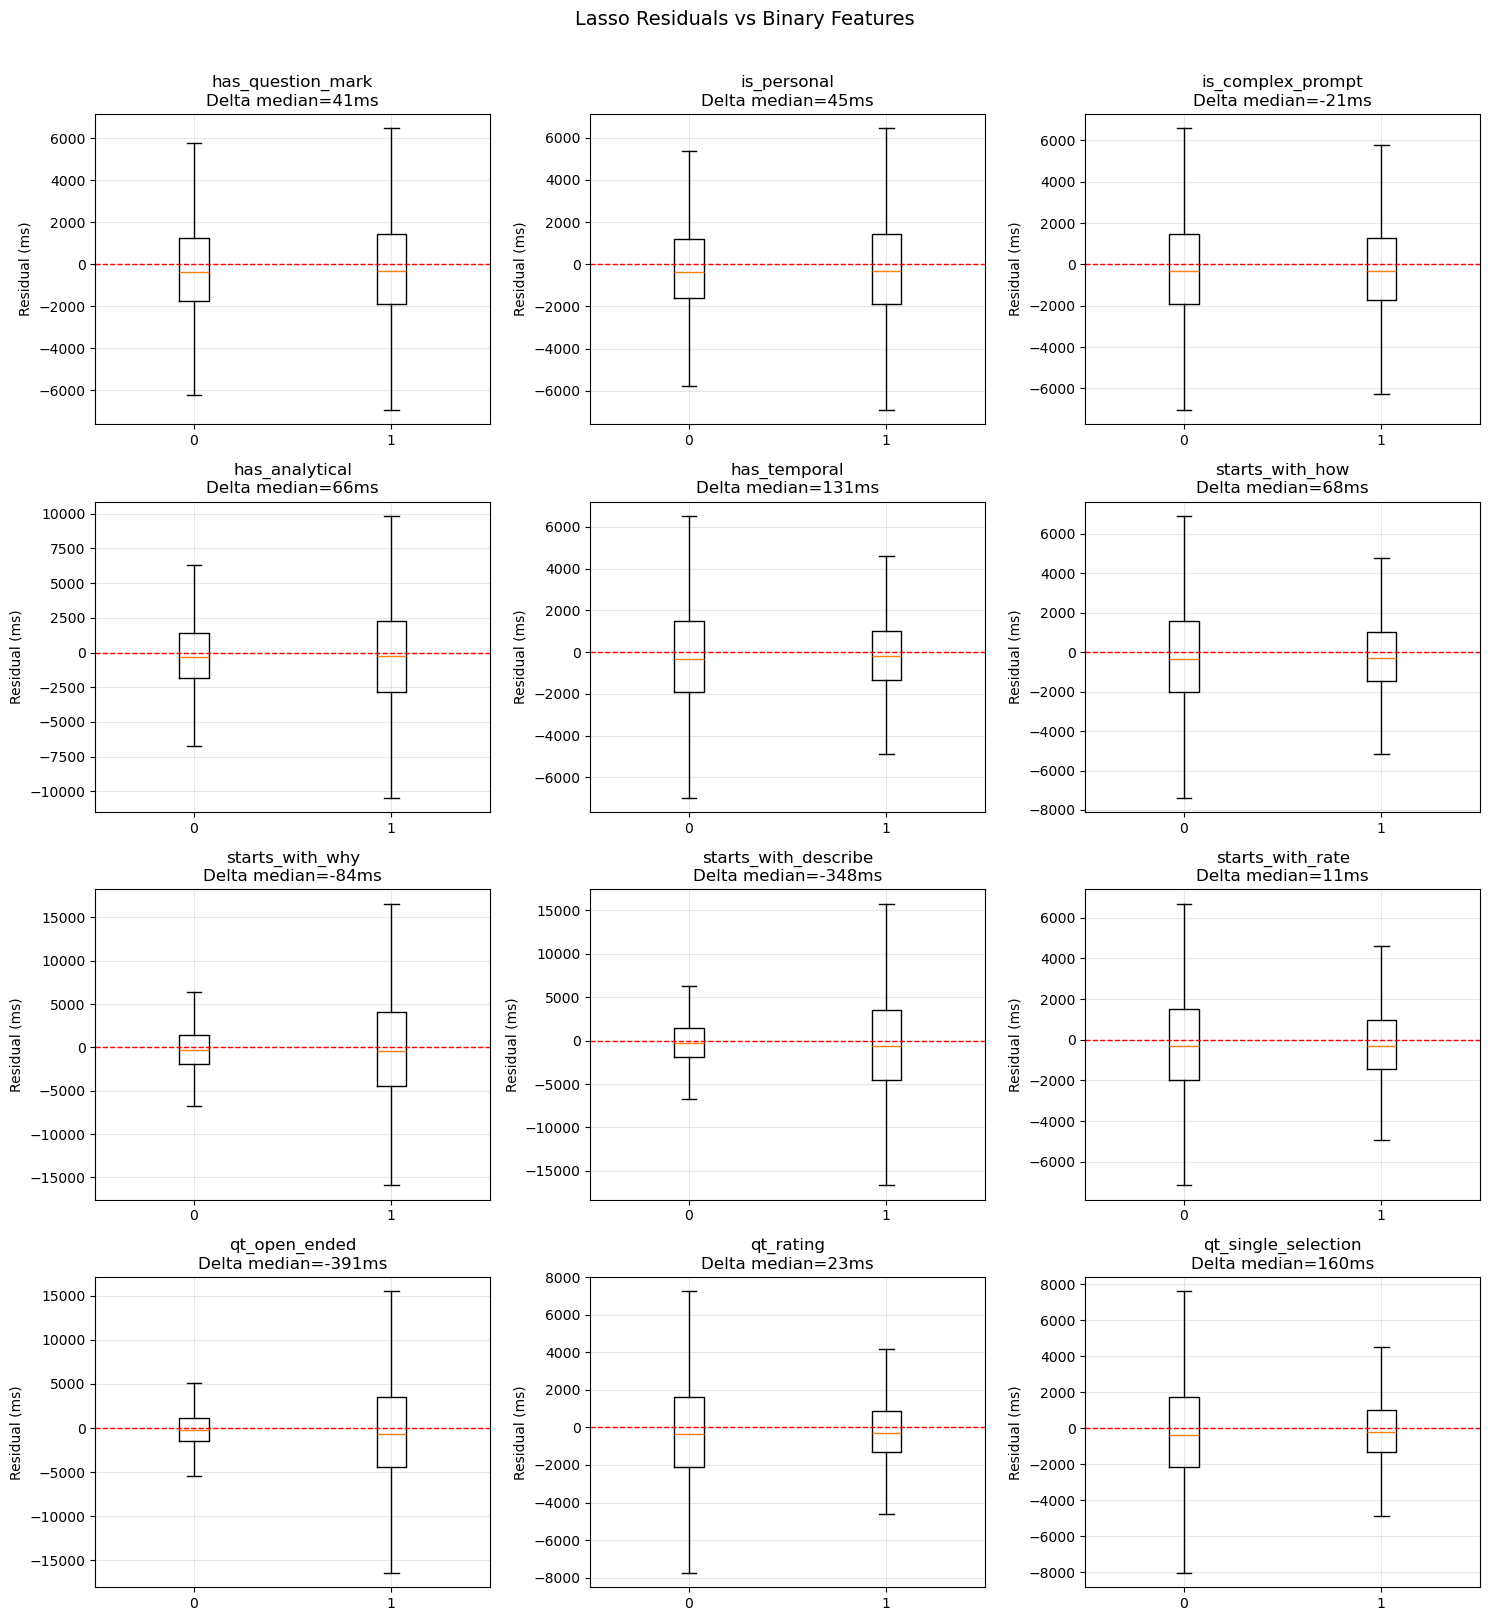

In [17]:
n_cols = 3
n_rows = int(np.ceil(len(binary_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(binary_features):
    group_0 = lasso_residuals[X_test[feature] == 0]
    group_1 = lasso_residuals[X_test[feature] == 1]

    axes[i].boxplot(
        [group_0, group_1],
        labels=['0', '1'],
        showfliers=False
    )
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)

    # Median difference → practical significance
    med_diff = group_1.median() - group_0.median()

    axes[i].set_title(f"{feature}\nDelta median={med_diff:.0f}ms")
    axes[i].set_ylabel('Residual (ms)')
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Lasso Residuals vs Binary Features',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# Binary features: no systematic bias across any feature. The small deviations in
# qt_open_ended (Δmedian=-391ms) and starts_with_describe (Δmedian=-348ms) reflect natural
# user-level variability in open_ended responses, not model misspecification.

In [ ]:
# Overall: residuals show no evidence of systematic misspecification. The remaining error
# is driven by inherent variability in user behavior that question-level features cannot
# capture, setting a natural performance ceiling for both Lasso and LightGBM. However,
# LightGBM may partially overcome this ceiling by learning interactions between question
# type and prompt-level features — for example combining qt_open_ended with starts_with_describe
# — which the Lasso cannot capture by design.

### LightGbm

#### test for basic model

In [ ]:
from sklearn.model_selection import GroupKFold
import lightgbm as lgb
# try lightgbm lwith lasso features for fair comparison on the same features 

np.random.seed(42)
idx = np.random.choice(len(df_train), size=1_000_000, replace=False)

df_sample = df_train.iloc[idx]
X_sample = df_sample[lasso_features].astype(float)
y_sample = df_sample['answer_time_ms']
groups = df_sample['response_id']

gkf = GroupKFold(n_splits=5)
fold_maes, fold_r2s = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_sample, y_sample, groups)):
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='mae',
        verbosity=-1,
        random_state=42
    )
    model.fit(X_sample.iloc[train_idx], y_sample.iloc[train_idx])
    preds = model.predict(X_sample.iloc[test_idx])
    fold_maes.append(mean_absolute_error(y_sample.iloc[test_idx], preds))
    fold_r2s.append(r2_score(y_sample.iloc[test_idx], preds))

mean_mae = np.mean(fold_maes)
std_mae  = np.std(fold_maes)
r2_lgbm = np.mean(fold_r2s)

print(f"size=1.000.000: mae={mean_mae:,.0f} with std of {std_mae:.0f}ms")
print("on test set:")
print(f"mae: {mean_mae:,.0f} ms = {mean_mae/1000:.2f} sec")
print(f"r squared: {r2_lgbm:.4f}")
print(f"light vs baseline:")
print(f"mae: {(baseline_mae - mean_mae)/baseline_mae*100:.2f}%")
print(f"r squared: {r2_lgbm - baseline_r2:.4f}")
print(f"light vs lasso:")
print(f"mae: {(mae_lasso - mean_mae)/mae_lasso*100:.2f}%")
print(f"r squared: {r2_lgbm - r2_lasso:.4f}")

# size=1.000.000: mae=2,407 with std of 2ms
# on test set:
# mae: 2,407 ms = 2.41 sec
# r squared: 0.8453
# light vs baseline:
# mae: 13.00%
# r squared: 0.0328
# light vs lasso:
# mae: 8.44%
# r squared: 0.0180

size=1.000.000: mae=2,407 with std of 2ms
on test set:
mae: 2,407 ms = 2.41 sec
r squared: 0.8453
light vs baseline:
mae: 13.00%
r squared: 0.0328
light vs lasso:
mae: 8.44%
r squared: 0.0180


In [8]:
from sklearn.model_selection import GroupKFold
import lightgbm as lgb

# following the same process i am training a simple lightgbm with cv with respect to reponse id in order to avoid leakage from train 
# dataset to see if it is worth my time

np.random.seed(42)
idx = np.random.choice(len(df_train), size=1_000_000, replace=False)

df_sample = df_train.iloc[idx]
X_sample = df_sample[feature_cols].astype(float)
y_sample = df_sample['answer_time_ms']
groups = df_sample['response_id']

gkf = GroupKFold(n_splits=5)
fold_maes, fold_r2s = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_sample, y_sample, groups)):
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='mae',
        verbosity=-1,
        random_state=42
    )
    model.fit(X_sample.iloc[train_idx], y_sample.iloc[train_idx])
    preds = model.predict(X_sample.iloc[test_idx])
    fold_maes.append(mean_absolute_error(y_sample.iloc[test_idx], preds))
    fold_r2s.append(r2_score(y_sample.iloc[test_idx], preds))

mean_mae = np.mean(fold_maes)
std_mae  = np.std(fold_maes)
r2_lgbm = np.mean(fold_r2s)

print(f"size=1.000.000: mae={mean_mae:,.0f} with std of {std_mae:.0f}ms")
print("on test set:")
print(f"mae: {mean_mae:,.0f} ms = {mean_mae/1000:.2f} sec")
print(f"r squared: {r2_lgbm:.4f}")
print(f"light vs baseline:")
print(f"mae: {(baseline_mae - mean_mae)/baseline_mae*100:.2f}%")
print(f"r squared: {r2_lgbm - baseline_r2:.4f}")
print(f"light vs lasso:")
print(f"mae: {(mae_lasso - mean_mae)/mae_lasso*100:.2f}%")
print(f"r squared: {r2_lgbm - r2_lasso:.4f}")

size=1.000.000: mae=2,382 with std of 2ms
on test set:
mae: 2,382 ms = 2.38 sec
r squared: 0.8470
light vs baseline:
mae: 13.92%
r squared: 0.0345
light vs lasso:
mae: 9.21%
r squared: 0.0192


#### Tuning with optuna on subset of train

i cannot use the entire train dataset to tune it due to ram and time limitation thus i select a subsample of 500.000 rows to find better suited features . later i wil find the best numebr of data to train my model to based on the optimisation of the mae. 
it would be optimal if i tuned lightgbm on these amount of data but agaian time-ram limitationa

In [10]:
# optuna tuning for lightgbm

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # subsample for fast tuning
    np.random.seed(trial.number)
    sample_idx = np.random.choice(len(X_train), size=1_000_000, replace=False)
    X_tr = X_train.iloc[sample_idx]
    y_tr = y_train.iloc[sample_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1) # no printing
        ]
    )

    y_pred = model.predict(X_test)
    return mean_absolute_error(y_test, y_pred)

In [11]:
print("trying optuna tuning for 100 trials")
study = optuna.create_study(direction='minimize') # set to minimise mae
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"best mae: {study.best_value:,.0f} ms")
print(f"best params: {study.best_params}")

# best params: {'n_estimators': 695, 'learning_rate': 0.14891409161262667, 'num_leaves': 145, 'max_depth': 9, 'min_child_samples': 11, 'subsample': 0.5264838523382533, 'colsample_bytree': 0.7356231181383541, 'reg_alpha': 0.0031666240726410536, 'reg_lambda': 1.1566706516462138e-05}


trying optuna tuning for 100 trials


Best trial: 48. Best value: 2184.79: 100%|██████████| 100/100 [1:03:08<00:00, 37.88s/it]

best mae: 2,185 ms
best params: {'n_estimators': 695, 'learning_rate': 0.14891409161262667, 'num_leaves': 145, 'max_depth': 9, 'min_child_samples': 11, 'subsample': 0.5264838523382533, 'colsample_bytree': 0.7356231181383541, 'reg_alpha': 0.0031666240726410536, 'reg_lambda': 1.1566706516462138e-05}


In [9]:
best_params= {
    'n_estimators': 695, 
    'learning_rate': 0.14891409161262667, 
    'num_leaves': 145,
    'max_depth': 9, 
    'min_child_samples': 11,
    'subsample': 0.5264838523382533, 
    'colsample_bytree': 0.7356231181383541,
    'reg_alpha': 0.0031666240726410536, 
    'reg_lambda': 1.1566706516462138e-05
    }



#### Cross validation with best params found 

In [19]:
np.random.seed(42)
# now train on the entire dataset with cv and evaluate if the params are okay because i found them in a subsample 
X_cv = df_train[feature_cols].astype(float)
y_cv = df_train['answer_time_ms']
groups = df_train['response_id']

gkf = GroupKFold(n_splits=5)
cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cv, y_cv, groups)):
    model = lgb.LGBMRegressor(
        **study.best_params,
        objective='regression',
        verbosity=-1,
        random_state=42
    )
    model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
    preds = model.predict(X_cv.iloc[test_idx])

    mae_best_lgbm = mean_absolute_error(y_cv.iloc[test_idx], preds)
    rmse_best_lgbm = np.sqrt(mean_squared_error(y_cv.iloc[test_idx], preds))
    r2_best_lgbm = r2_score(y_cv.iloc[test_idx], preds)
    cv_maes.append(mae_best_lgbm)
    cv_rmses.append(rmse_best_lgbm)
    cv_r2s.append(r2_best_lgbm)
    print(f"Fold {fold+1}: MAE={mae_best_lgbm:,.0f}ms  R²={r2_best_lgbm:.4f}")
    
best_cv_mae = np.mean(cv_maes)
best_cv_r2 = np.mean(cv_r2s)

print(f"cv results for light gbm and 5 fold cv")
print(f"mae: {best_cv_mae:,.0f} with std of {np.std(cv_maes):.0f}ms")
print(f"r squared: {best_cv_r2:.4f} with std of {np.std(cv_r2s):.4f}")

# Fold 1: MAE=2,183ms  R²=0.8558
# Fold 2: MAE=2,182ms  R²=0.8561
# Fold 3: MAE=2,180ms  R²=0.8568
# Fold 4: MAE=2,182ms  R²=0.8562
# Fold 5: MAE=2,184ms  R²=0.8561
# cv results for light gbm and 5 fold cv
# mae: 2,182 with std of 1ms
# r squared: 0.8562 with std of 0.0003

Fold 1: MAE=2,183ms  R²=0.8558
Fold 2: MAE=2,182ms  R²=0.8561
Fold 3: MAE=2,180ms  R²=0.8568
Fold 4: MAE=2,182ms  R²=0.8562
Fold 5: MAE=2,184ms  R²=0.8561
cv results for light gbm and 5 fold cv
mae: 2,182 with std of 1ms
r squared: 0.8562 with std of 0.0003


#### Final Training

In [11]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    # study.best_params,
    **best_params,
    objective='regression',
    verbosity=-1,
    random_state=42
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

y_pred_lgb = lgb_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_lgb)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_best = r2_score(y_test, y_pred_lgb)
y_pred_best = y_pred_lgb

print(f"LightGBM results:")
print(f"mae: {mae_best:,.0f} ms ({mae_best/1000:.1f} sec)")
print(f"rmse: {rmse_best:,.0f} ms ({rmse_best/1000:.1f} sec)")
print(f"r squared: {r2_best:.4f}")

print(f"lightgbm vs baseline:")
print(f"mae: {(baseline_mae - mae_best)/baseline_mae*100:.1f}%")
print(f"r squared: {r2_best - baseline_r2:.4f}")

print(f"lightgbm vs lasso:")
print(f"mae: {(mae_lasso - mae_best)/mae_lasso*100:.1f}%")

# LightGBM results:
# mae: 2,182 ms (2.2 sec)
# rmse: 3,703 ms (3.7 sec)
# r squared: 0.8566
# lightgbm vs baseline:
# mae: 21.1%
# r squared: 0.0441
# lightgbm vs lasso:
# mae: 16.8%

python(92640) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


LightGBM results:
mae: 2,182 ms (2.2 sec)
rmse: 3,703 ms (3.7 sec)
r squared: 0.8566
lightgbm vs baseline:
mae: 21.1%
r squared: 0.0441
lightgbm vs lasso:
mae: 16.8%


In [ ]:
# Baseline: mae=2,767ms r²=0.8125
# Lasso (lasso_features): mae=2,623ms r²=0.8277 +5.2% vs baseline
# LightGBM (lasso_features no tuning): mae=2,407ms r²=0.8453 +8.4% vs Lasso - algorithm gain
# LightGBM (all features no tuning): mae=2,382ms r²=0.8470 +1.0% vs above - feature gain
# LightGBM (all features tuned): mae=2,182ms r²=0.8566 +8.4% vs above - tuning gain

In [19]:
from sklearn.inspection import permutation_importance

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=50_000, replace=False)
X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

result = permutation_importance(
    lgb_model,
    X_test_sample, y_test_sample,
    n_repeats=10,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_mae_gain': result.importances_mean,
    'std': result.importances_std
}).sort_values('mean_mae_gain', ascending=False)

print(perm_importance)

python(8004) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8005) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8006) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8007) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8008) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8009) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8010) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8011) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(8012) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


                     feature  mean_mae_gain        std
0              qt_open_ended    3867.875335  16.160064
3                  qt_rating    1212.141005   9.455452
5   avg_answer_choice_length     922.006354   4.272124
1      qt_multiple_selection     524.213140   5.137414
2        qt_single_selection     329.036705   4.167648
6                 word_count     276.567209   1.845575
8            avg_word_length     187.022918   2.394477
11               readability     181.569297   2.560498
7              prompt_length     177.398708   2.195726
24        position_in_survey      95.717659   2.193117
22          starts_with_rate      92.819708   1.091171
4         num_answer_choices      89.808093   0.702335
9              pct_big_words      85.964414   0.849832
20           starts_with_how      64.997674   1.217982
25   survey_difficulty_score      51.102647   1.061189
23          open_ended_ratio      36.353543   0.661232
10          type_token_ratio      27.530798   0.631124
18        

In [20]:
parent_folder = os.path.dirname(os.getcwd())
filepath = f'{parent_folder}/results/perm_importnaces.csv'

perm_importance.to_csv(filepath)

In [ ]:
# permutation importance analysis — lightgbm vs lasso

# question type features dominate in both models
# qt_open_ended (3867ms) and qt_rating (1212ms) are top two features
# consistent with lasso coefficients and baseline r_squared = 0.81
# question type is by far the strongest signal regardless of model

# avg_answer_choice_length (922ms) is 3rd most important in lightgbm
# in lasso it had near-zero coefficient (74ms)
# confirms relationship is non-linear: lightgbm captures it, lasso cannot

# qt_multiple_selection (524ms) is 4th most important
# lasso dropped it (p=-0.03)
# validates keeping it for lightgbm and explains part of 1% mae gain in experiment 2

# avg_word_length (187ms) and readability (181ms) show meaningful importance in lightgbm
# small/conflicting coefficients in lasso due to multicollinearity with prompt_length and word_count
# lightgbm evaluates independently and recovers signal lost in lasso

# pct_big_words (85ms) and type_token_ratio (27ms) dropped from lasso (p≈0, s≈0)
# show small signal in lightgbm via interactions with question type

# cat_* features all below 15ms
# consistent with dropping from lasso
# lightgbm retains but contribution negligible

# has_negation (-0.07ms) is only feature with negative importance (~0)
# confirms dropping from lasso was correct
# adds no value in lightgbm either

# key takeaway:
# gap in avg_answer_choice_length and qt_multiple_selection between lasso and lightgbm
# largely explains 8.4% mae gain
# lightgbm recovers non-linear signal that lasso treated as noise or confounded

In [12]:
import pickle 
parent_folder = os.path.dirname(os.getcwd())
folderpath = f'{parent_folder}/results/'
    
with open(f'{folderpath}best_lgb_final.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

np.save(f'{folderpath}y_pred_best_final.npy', y_pred_best)

with open(f'{folderpath}scaler_final.pkl', 'wb') as f:
    pickle.dump(scaler, f)

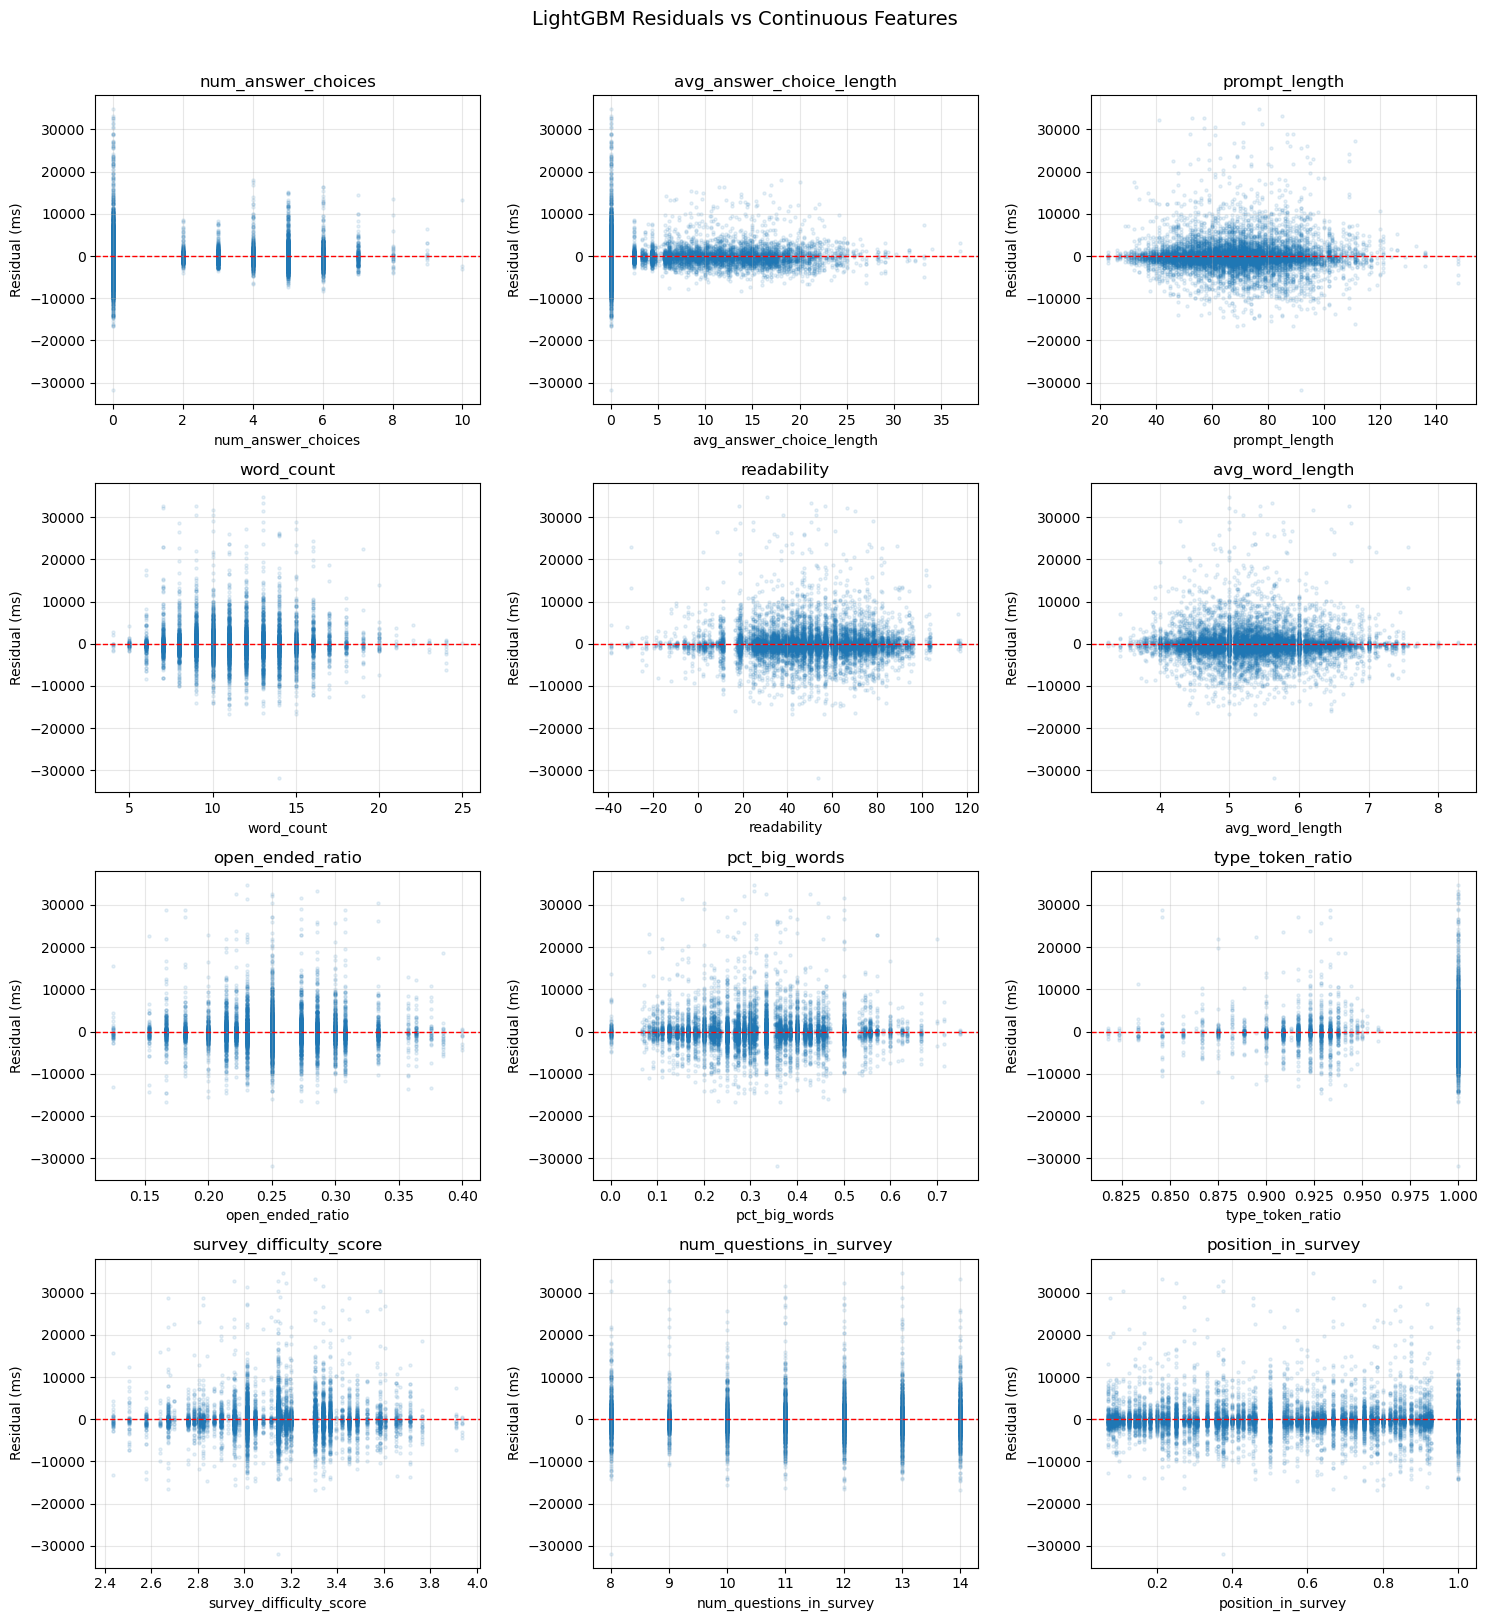

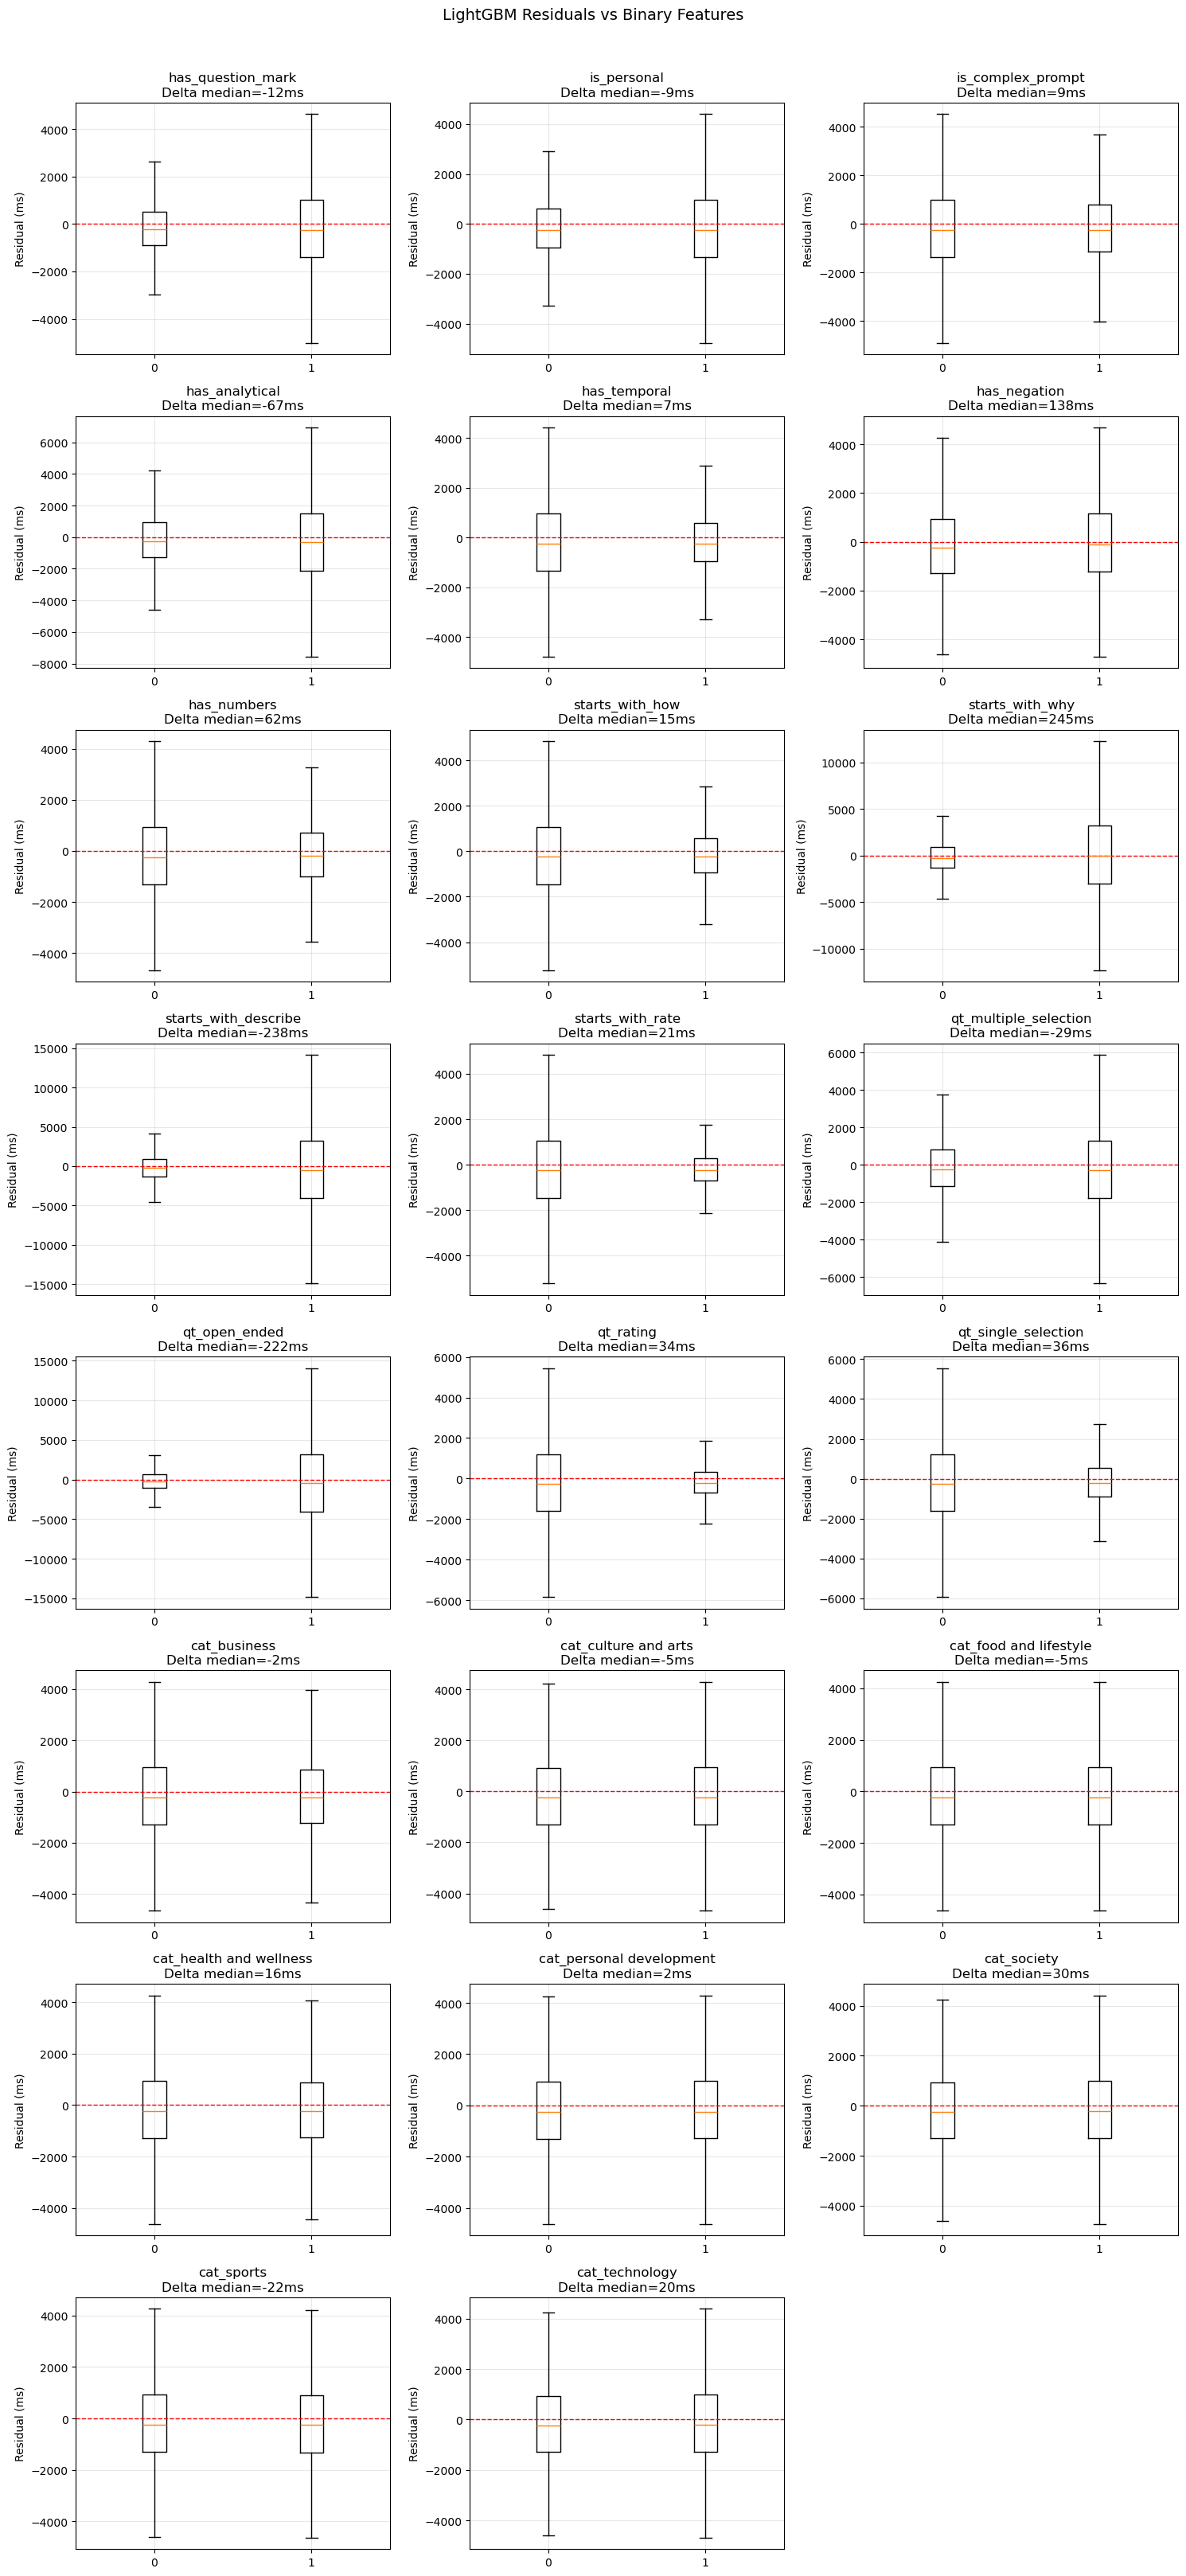

In [21]:
# residual analysis 
import numpy as np

parent_folder = os.path.dirname(os.getcwd())
folderpath = f'{parent_folder}/results/'
y_pred_lgb = np.load(f'{folderpath}y_pred_best_final.npy')

lgb_residuals = y_test - y_pred_lgb
lgb_residuals = y_test - y_pred_lgb

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=10_000, replace=False)

residuals_sample = lgb_residuals.iloc[sample_idx]
X_test_sample    = X_test[feature_cols].iloc[sample_idx]

# continuous features
continuous_features = [
    'num_answer_choices', 'avg_answer_choice_length',
     'prompt_length', 'word_count',
    'readability', 'avg_word_length', 'open_ended_ratio',
    'pct_big_words', 'type_token_ratio',
    'survey_difficulty_score', 'num_questions_in_survey',
    'position_in_survey'
]

n_cols = 3
n_rows = int(np.ceil(len(continuous_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    axes[i].scatter(
        X_test_sample[feature],
        residuals_sample,
        alpha=0.1, s=5
    )
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Residual (ms)')
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LightGBM Residuals vs Continuous Features',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# binary features — includes qt_multiple_selection unlike Lasso
binary_features = [
    'has_question_mark', 'is_personal', 'is_complex_prompt',
    'has_analytical', 'has_temporal', 'has_negation', 'has_numbers',
    'starts_with_how', 'starts_with_why', 'starts_with_describe', 'starts_with_rate',
    'qt_multiple_selection', 'qt_open_ended', 'qt_rating', 'qt_single_selection',
    'cat_business', 'cat_culture and arts', 'cat_food and lifestyle',
    'cat_health and wellness', 'cat_personal development',
    'cat_society', 'cat_sports', 'cat_technology'
]

n_cols = 3
n_rows = int(np.ceil(len(binary_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(binary_features):
    group_0 = lgb_residuals[X_test[feature] == 0]
    group_1 = lgb_residuals[X_test[feature] == 1]

    axes[i].boxplot(
        [group_0, group_1],
        labels=['0', '1'],
        showfliers=False
    )
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)

    med_diff = group_1.median() - group_0.median()
    axes[i].set_title(f"{feature}\nDelta median={med_diff:.0f}ms")
    axes[i].set_ylabel('Residual (ms)')
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('LightGBM Residuals vs Binary Features',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# lightgbm residual analysis — comparison with lasso

# continuous features:
# residual patterns almost identical to lasso across all features
# variance pattern in num_answer_choices and avg_answer_choice_length remains unchanged
# confirms it reflects underlying question type distribution at each x
# not missing non-linear signal — lightgbm does not correct it despite high
# permutation importance of avg_answer_choice_length (922ms)
# one new pattern: type_token_ratio shows high variance at 1.0
# likely due to very short prompts where every word is unique, making response time unpredictable
# all other continuous features show symmetric residuals with no pattern, same as lasso

# binary features:
# lightgbm shows meaningful improvement over lasso in two areas
# qt_open_ended bias reduced from -391ms to -222ms
# lightgbm better captures open_ended response time likely via interactions with prompt-level features
# qt_multiple_selection (Δmedian=-29ms) is effectively unbiased
# validates keeping it only for lightgbm given its non-linear signal (s=0.21, p=-0.03)

# two regressions vs lasso worth noting:
# starts_with_why bias increased from -84ms to +245ms
# lightgbm underestimates questions starting with "why", likely too sparse to learn reliably
# has_negation shows new bias of 138ms that was effectively zero in lasso
# despite near-zero permutation importance — suggests subtle interaction with other features

# cat_* features all below 30ms Δmedian — negligible
# consistent with dropping them from lasso and low permutation importance in lightgbm

# overall:
# lightgbm gain over lasso comes mainly from better modeling of qt_open_ended
# and capturing qt_multiple_selection, not from correcting non-linearity in continuous features
# remaining error driven by inherent user-level variability
# neither model can capture this from question-level features alone

#### LOI Evaluation

In [ ]:
# evaluation of model
# loi analysis
df_test['predicted_ms'] = y_pred_best
loi = df_test.groupby(['response_id', 'survey_id']).agg(
    actual_loi = ('answer_time_ms', 'sum'),
    predicted_loi = ('predicted_ms', 'sum'),
    num_questions = ('answer_time_ms', 'count')
).reset_index()

In [14]:
print(f"Total surveys in test: {len(loi):,}")
print(f"Actual LOI distribution:")
print(loi['actual_loi'].describe())
print(f"Predicted LOI distribution:")
print(loi['predicted_loi'].describe())

# Total surveys in test: 76,514
# Actual LOI distribution:
# count     76514.000000
# mean     111226.897378
# std       31112.614496
# min        8855.000000
# 25%       88855.250000
# 50%      110535.500000
# 75%      132826.750000
# max      252757.000000
# Name: actual_loi, dtype: float64
# Predicted LOI distribution:
# count     76514.000000
# mean     111168.286687
# std       29045.614937
# min       12100.533571
# 25%       90341.618634
# 50%      111236.221382
# 75%      132217.537918
# max      203702.973565

Total surveys in test: 76,514
Actual LOI distribution:
count     76514.000000
mean     111226.897378
std       31112.614496
min        8855.000000
25%       88855.250000
50%      110535.500000
75%      132826.750000
max      252757.000000
Name: actual_loi, dtype: float64
Predicted LOI distribution:
count     76514.000000
mean     111168.286687
std       29045.614937
min       12100.533571
25%       90341.618634
50%      111236.221382
75%      132217.537918
max      203702.973565
Name: predicted_loi, dtype: float64


In [15]:
# Metrics
loi_mae = mean_absolute_error(loi['actual_loi'], loi['predicted_loi'])
loi_rmse = np.sqrt(mean_squared_error(loi['actual_loi'], loi['predicted_loi']))
loi_r2 = r2_score(loi['actual_loi'], loi['predicted_loi'])

print(f"LOI results:")
print(f"mae: {loi_mae/1000:.1f} sec  ({loi_mae/60000:.2f} min)")
print(f"rmse: {loi_rmse/1000:.1f} sec  ({loi_rmse/60000:.2f} min)")
print(f"r squared: {loi_r2:.4f}")

# LOI results:
# mae: 8.7 sec  (0.14 min)
# rmse: 11.4 sec  (0.19 min)
# r squared: 0.8666

LOI results:
mae: 8.7 sec  (0.14 min)
rmse: 11.4 sec  (0.19 min)
r squared: 0.8666


#### Residual Analysis

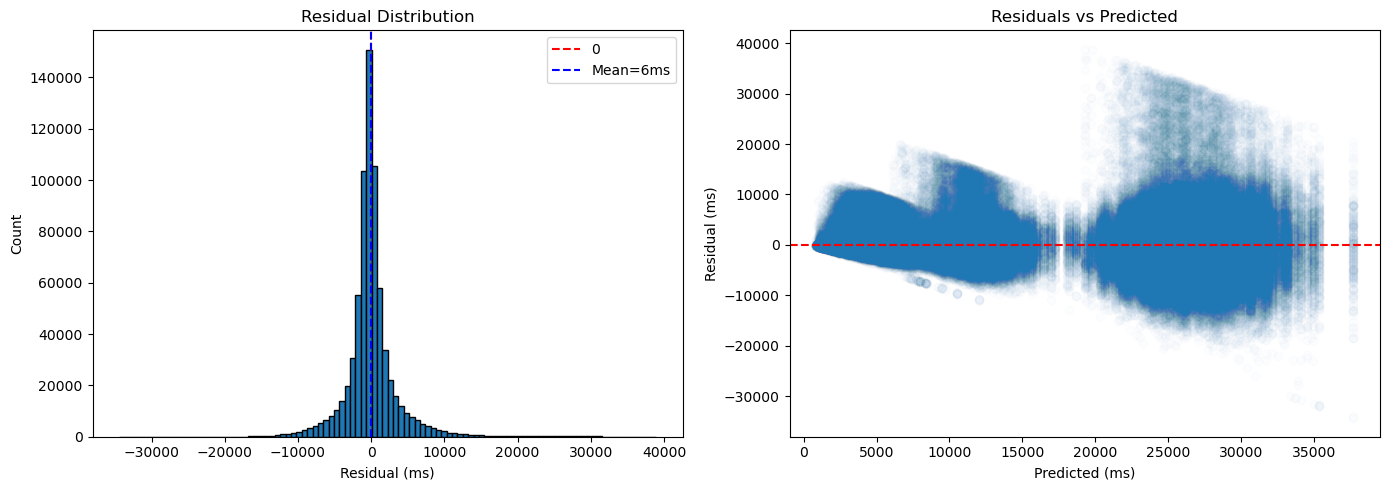

Mean residual:   6 ms
Median residual: -241 ms
Std residual:    3703 ms


In [16]:
import matplotlib.pyplot as plt

residuals = df_test['answer_time_ms'] - df_test['predicted_ms']
df_test['residual'] = residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=100, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', label='0')
axes[0].axvline(x=residuals.mean(), color='blue', 
                linestyle='--', label=f'Mean={residuals.mean():.0f}ms')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(df_test['predicted_ms'], residuals, alpha=0.01)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted (ms)')
axes[1].set_ylabel('Residual (ms)')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.0f} ms")
print(f"Median residual: {residuals.median():.0f} ms")
print(f"Std residual: {residuals.std():.0f} ms")

In [ ]:
# Residual analysis confirms model is unbiased (mean=6ms). Three distinct clusters reflect the question type
# distribution: rating/single (fast, small residuals), multiple (medium), open_ended (slow, large residuals).
#T he  shape for open_ended predictions reveal heteroscedasticity — larger predictions carry larger
# errors. This is consistent with the high individual variance in open_ended responses , where user behavior dominates over question-level features.

In [17]:
df_test['abs_residual'] = abs(df_test['residual'])
print(df_test.nlargest(10, 'abs_residual')[
    ['_qtype', 'answer_time_ms', 'predicted_ms', 'residual']
])

                _qtype  answer_time_ms  predicted_ms      residual
2969220  qt_open_ended           58171  19272.929937  38898.070063
645610   qt_open_ended           58419  19762.647854  38656.352146
1742881  qt_open_ended           56499  19272.929937  37226.070063
1602544  qt_open_ended           57157  20380.637940  36776.362060
649735   qt_open_ended           56026  19272.929937  36753.070063
976615   qt_open_ended           58028  21334.890667  36693.109333
3519788  qt_open_ended           58162  21480.095144  36681.904856
1855436  qt_open_ended           56135  19468.085541  36666.914459
1596786  qt_open_ended           58425  21959.928041  36465.071959
1332648  qt_open_ended           58183  22065.249968  36117.750032


In [10]:
import pandas as pd

perm_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_mae_gain': result.importances_mean,
    'std': result.importances_std
}).sort_values('mean_mae_gain', ascending=False)

perm_importance.to_csv('perm_importance.csv')

In [23]:
df_test['abs_error'] = abs(y_test-y_pred_best)
print(df_test.groupby('_qtype')['abs_error'].agg(mean='mean', median='median').round(0).sort_values('mean',ascending=False))

#                          mean  median
# _qtype                               
# qt_open_ended          4685.0  3634.0
# qt_multiple_selection  2067.0  1553.0
# qt_single_selection    1096.0   766.0
# qt_rating               887.0   564.0

                         mean  median
_qtype                               
qt_open_ended          4685.0  3634.0
qt_multiple_selection  2067.0  1553.0
qt_single_selection    1096.0   766.0
qt_rating               887.0   564.0


In [24]:
# i need to see if the errors are okay based on the std of each question type or my model is bad
stats = df_test.groupby('_qtype').agg(
    actual_std  = ('answer_time_ms', 'std'),
    actual_mean = ('answer_time_ms', 'mean'),
    mae = ('abs_error', 'mean')
).round(0)

# Coefficient of Variation (CV) = std / mean normalised variation 
stats['actual_cv'] = stats['actual_std'] / stats['actual_mean']
stats['mae_pct'] = stats['mae'] / stats['actual_mean']
stats['mae_vs_std']  = stats['mae'] / stats['actual_std']

print(stats[['actual_std', 'mae', 'actual_cv', 
             'mae_pct', 'mae_vs_std']].round(2))

                       actual_std     mae  actual_cv  mae_pct  mae_vs_std
_qtype                                                                   
qt_multiple_selection      3460.0  2067.0       0.31     0.18        0.60
qt_open_ended              7038.0  4685.0       0.27     0.18        0.67
qt_rating                  2179.0   887.0       0.54     0.22        0.41
qt_single_selection        2174.0  1096.0       0.40     0.20        0.50


In [ ]:
# MAE as % of mean is consistent across all question types 18-22 confirming that the model performs well regardless of question type.
# The higher absolute MAE for open_ended (4,685ms) simply reflects the fact that open_ended responses are naturally harder to predict — people vary a lot in
# how much they write. The std for open_ended (7,038ms) is more than 3x higher than for rating (2,179ms), so larger errors are expected.

In [26]:
df_test.columns

Index(['qt_open_ended', 'qt_multiple_selection', 'qt_single_selection',
       'qt_rating', 'num_answer_choices', 'avg_answer_choice_length',
       'word_count', 'prompt_length', 'avg_word_length', 'pct_big_words',
       'type_token_ratio', 'readability', 'has_question_mark', 'is_personal',
       'has_analytical', 'has_negation', 'has_temporal', 'has_numbers',
       'is_complex_prompt', 'starts_with_why', 'starts_with_how',
       'starts_with_describe', 'starts_with_rate', 'open_ended_ratio',
       'position_in_survey', 'survey_difficulty_score',
       'num_questions_in_survey', 'cat_business', 'cat_culture and arts',
       'cat_food and lifestyle', 'cat_health and wellness',
       'cat_personal development', 'cat_society', 'cat_sports',
       'cat_technology', 'response_id', 'survey_id', 'answer_time_ms',
       '_qtype', 'predicted_ms', 'residual', 'abs_residual', 'abs_error'],
      dtype='str')

### find edge cases

In [ ]:
# 1. Question type combinations per survey
type_combos = df_test.groupby('survey_id').agg(
    has_open = ('qt_open_ended', 'sum'),
    has_multiple = ('qt_multiple_selection', 'sum'),
    has_single = ('qt_single_selection', 'sum'),
    has_rating = ('qt_rating', 'sum'),
    n_questions = ('qt_open_ended', 'count')
).reset_index()

type_combos['has_open'] = type_combos['has_open'] > 0
type_combos['has_multiple'] = type_combos['has_multiple'] > 0
type_combos['has_single'] = type_combos['has_single'] > 0
type_combos['has_rating'] = type_combos['has_rating'] > 0

print("Question type combinations:")
print(type_combos[['has_open','has_multiple',
                   'has_single','has_rating']].value_counts())

# 2. min max questions
print(f"\nMin questions: {type_combos['n_questions'].min()}")
print(f"Max questions: {type_combos['n_questions'].max()}")
print(f"Min survey_id: {type_combos.loc[type_combos['n_questions'].idxmin(), 'survey_id']}")
print(f"Max survey_id: {type_combos.loc[type_combos['n_questions'].idxmax(), 'survey_id']}")

# 3. categories
print(f"Categories in test set:")
cat_cols = [c for c in df_test.columns if c.startswith('cat_')]
for cat in cat_cols:
    n = df_test.groupby('survey_id')[cat].max().sum()
    print(f"  {cat}: {n} surveys")

# 4. loi distribution
loi = df_test.groupby(['response_id', 'survey_id'])['answer_time_ms'].sum()
print(f"LOI distribution (per user per survey):")
print(loi.describe())

# min max survey
loi_per_survey = loi.reset_index()
loi_per_survey.columns = ['response_id', 'survey_id', 'loi_ms']

mean_loi = loi_per_survey.groupby('survey_id')['loi_ms'].mean()
print(f"Mean LOI ανά survey:")
print(mean_loi.describe())
print(f"Min mean LOI survey: {mean_loi.idxmin()} → {mean_loi.min()/1000:.1f}sec")
print(f"Max mean LOI survey: {mean_loi.idxmax()} → {mean_loi.max()/1000:.1f}sec")

Question type combinations:
has_open  has_multiple  has_single  has_rating
True      True          True        True          331
Name: count, dtype: int64

Min questions: 688
Max questions: 4954
Min survey_id: 4d5cc3c5-f5a4-47bd-89e4-812f7b5c2e88
Max survey_id: b58f8d56-a4c0-497a-9d3f-9695ca4e485f

Categories in test set:
  cat_business: 28 surveys
  cat_culture and arts: 80 surveys
  cat_food and lifestyle: 32 surveys
  cat_health and wellness: 28 surveys
  cat_personal development: 56 surveys
  cat_society: 36 surveys
  cat_sports: 55 surveys
  cat_technology: 12 surveys

LOI distribution (per user per survey):
count     76514.000000
mean     111226.897378
std       31112.614496
min        8855.000000
25%       88855.250000
50%      110535.500000
75%      132826.750000
max      252757.000000
Name: answer_time_ms, dtype: float64

Mean LOI ανά survey:
count       331.000000
mean     112324.254188
std       23099.302720
min       56106.321053
25%       91637.962619
50%      115197.30303

In [4]:
print("Categories in test set:")
cat_cols = [c for c in df_test.columns if c.startswith('cat_')]

cat_counts = {}

for cat in cat_cols:
    n = df_test.groupby('survey_id')[cat].max().sum()
    cat_counts[cat] = n
    print(f"  {cat}: {n} surveys")

# top 1
max_cat = max(cat_counts, key=cat_counts.get)

# lowest 1
min_cat = min(cat_counts, key=cat_counts.get)

print(f"\nTop category: {max_cat} ({cat_counts[max_cat]} surveys)")
print(f"Lowest category: {min_cat} ({cat_counts[min_cat]} surveys)")

Categories in test set:
  cat_business: 28 surveys
  cat_culture and arts: 80 surveys
  cat_food and lifestyle: 32 surveys
  cat_health and wellness: 28 surveys
  cat_personal development: 56 surveys
  cat_society: 36 surveys
  cat_sports: 55 surveys
  cat_technology: 12 surveys

Top category: cat_culture and arts (80 surveys)
Lowest category: cat_technology (12 surveys)


In [5]:
q_per_survey = df_test.groupby('survey_id')['num_questions_in_survey'].first()
print(f"Min questions: {q_per_survey.min()} → {q_per_survey.idxmin()}")
print(f"Max questions: {q_per_survey.max()} → {q_per_survey.idxmax()}")

# Min/Max LOI survey
mean_loi = (df_test.groupby(['response_id', 'survey_id'])['answer_time_ms']
            .sum()
            .reset_index()
            .groupby('survey_id')['answer_time_ms']
            .mean())
print(f"\nMin LOI survey: {mean_loi.idxmin()} → {mean_loi.min()/1000:.1f}sec")
print(f"Max LOI survey: {mean_loi.idxmax()} → {mean_loi.max()/1000:.1f}sec")

# Technology survey (rare category - 12 surveys)
tech_id = df_test[df_test['cat_technology'] == 1]['survey_id'].iloc[0]
print(f"\nTechnology survey: {tech_id}")

# Soccat_culture and artsiety survey (most common - 80 surveys)
arts_id = df_test[df_test['cat_culture and arts'] == 1]['survey_id'].iloc[0]
print(f"cat_culture and arts survey: {arts_id}")

Min questions: 8 → 04524663-d921-40ef-99a0-234bcf760e48
Max questions: 14 → 0923da37-b4b8-426c-a829-f2f3efcefd4a

Min LOI survey: 1d8f1f9b-cb53-4cd1-9a6a-fd75bd9ca388 → 56.1sec
Max LOI survey: a1fbd060-fa4f-474b-b771-f9b8b7f8f8a0 → 172.9sec

Technology survey: ed491772-afe2-4c36-8a47-529c5b27e101
cat_culture and arts survey: e084ee9b-1b23-4bd5-b1ee-1b2f5ef2b2d6
